In [1]:
import pandas as pd
import statsmodels as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse

In [99]:
def plot_model(x, y, pred, model_name:str, rmse:int, order:tuple, seasonal_order:list, exog:list):
    resid = y - pred
    plt.figure(figsize=(10, 4))
    plt.plot(x, y, label='billion cubic feet')
    plt.plot(x, pred, alpha=0.5, label='predicted')
    plt.plot(x, resid, alpha=0.5, label='residuals')
    plt.xlabel('In Weeks')
    plt.ylabel('billion cubic feet')
    plt.legend()
    plt.grid()
    plt.title('Underground Natural Gas Storage Volume Over Time')
    plt.suptitle(f"{model_name}, O:{order}, X:{exog}, S:{seasonal_order}, rmse:{rmse:.2f}")
    plt.savefig(f"{model_name}_{order}_S{seasonal_order}.png")
    plt.show()

In [2]:
from log_model import log_model

In [3]:
df = pd.read_excel("raw_data/ngshistory.xls", header=6)
df.head()

,Week ending,Source,East Region,Midwest Region,Mountain Region,Pacific Region,South Central Region,Salt,NonSalt,Total Lower 48
0,2010-01-01,Derived EIA Weekly Estimates,769,900,195,268,985,159,826,3117
1,2010-01-08,Derived EIA Weekly Estimates,703,820,185,257,886,123,763,2850
2,2010-01-15,Derived EIA Weekly Estimates,642,750,176,246,793,91,702,2607
3,2010-01-22,Derived EIA Weekly Estimates,616,710,171,235,789,102,687,2521
4,2010-01-29,Derived EIA Weekly Estimates,582,661,164,221,779,108,671,2406


In [6]:
df.columns

Index(['Week ending', 'Source', 'East Region', 'Midwest Region',
       'Mountain Region', 'Pacific Region', 'South Central Region', 'Salt',
       'NonSalt', 'Total Lower 48'],
      dtype='str')

In [18]:
label = df['Total Lower 48']

In [8]:
diffs = df['Week ending'].diff()
if not diffs[1:].nunique() == 1:
    print("not equidistant")
    first_diff = diffs.iloc[1]
    inconsistent = diffs[diffs != first_diff].dropna()
    print(inconsistent)

In [19]:
year_mean = label.rolling(window=52).mean()
df_diff = label.diff()

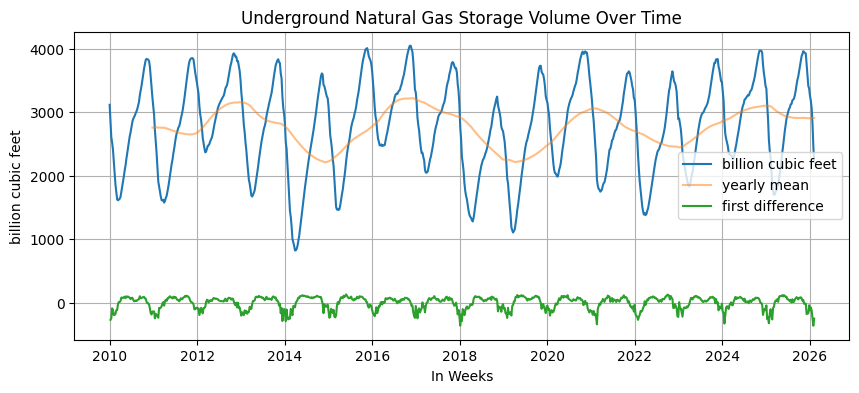

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(df['Week ending'], label, label='billion cubic feet')
plt.plot(df['Week ending'], year_mean, label='yearly mean', alpha=0.5)
plt.plot(df["Week ending"], df_diff, label='first difference')
plt.xlabel('In Weeks')
plt.ylabel('billion cubic feet')
plt.legend()
plt.grid()
plt.title('Underground Natural Gas Storage Volume Over Time')
plt.show();

In [21]:
autocorr_lst = [label.autocorr(i) for i in range(30)]
autocorr_lst.index(min(autocorr_lst))

27

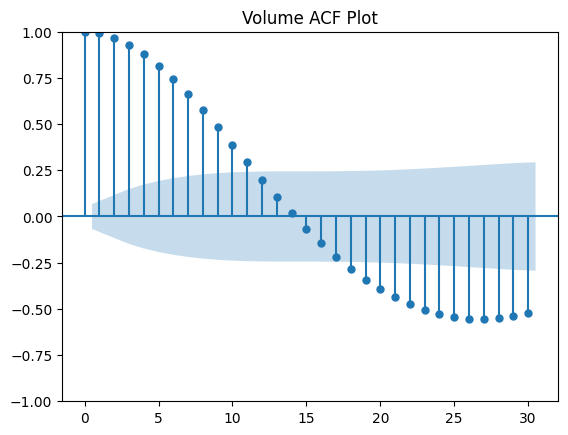

In [22]:
plot_acf(label, title = 'Volume ACF Plot')
plt.show()

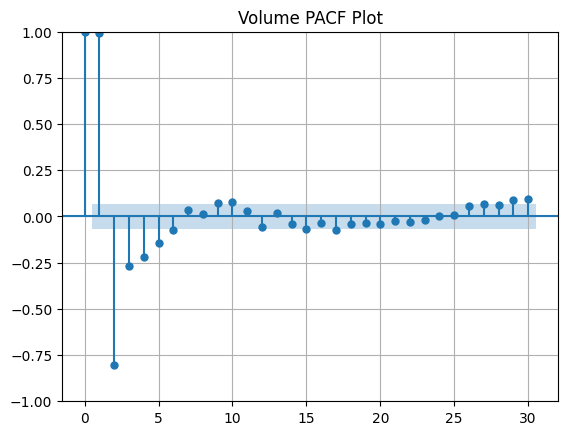

In [23]:
plot_pacf(label, title = 'Volume PACF Plot')
plt.grid()
plt.show()

In [25]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(label, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -7.381576238553729
p-value: 8.445370937524531e-11


In [39]:
sc52 = label.shift(52).rename("sc52")
sc26 = label.shift(26).rename("sc26")
feat = pd.concat([label, sc52, sc26], axis=1).dropna()
feat.corr()

,Total Lower 48,sc52,sc26
Total Lower 48,1.000000,0.808067,-0.565486
sc52,0.808067,1.000000,-0.568570
sc26,-0.565486,-0.568570,1.000000


In [ ]:
label2 = feat['Total Lower 48']


In [110]:
order=(5, 0, 5)
seasonal_order = (2, 1, 2, 52)
model2 = SARIMAX(label[:-104], order=order, seasonal_order=seasonal_order)
result2 = model2.fit()
result2.summary()

/Users/cyqmain/.work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/cyqmain/.work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                          Total Lower 48   No. Observations:                  737
Model:             SARIMAX(5, 0, 5)x(2, 1, [1, 2], 52)   Log Likelihood               -3601.209
Date:                                 Sat, 14 Feb 2026   AIC                           7232.418
Time:                                         12:02:05   BIC                           7300.359
Sample:                                              0   HQIC                          7258.707
                                                 - 737                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8393      0.102     -8.246      0.000      -1.039      -0.640
ar.L2          1.8087      0.072     25.091      0.000       1.667       1.950
ar.L3          1.8274      0.142     12.899      0.000       1.550       2.105
ar.L4         -0.8090      0.076    -10.683      0.000      -0.957      -0.661
ar.L5         -0.9877      0.086    -11.494      0.000      -1.156      -0.819
ma.L1          2.1341      0.137     15.620      0.000       1.866       2.402
ma.L2          0.5607      0.365      1.535      0.125      -0.155       1.277
ma.L3         -1.8263      0.384     -4.752      0.000      -2.580      -1.073
ma.L4         -1.5603      0.188     -8.317      0.000      -1.928      -1.193
ma.L5         -0.3082      0.039     -7.979      0.000      -0.384      -0.232
ar.S.L52       0.7170      0.123      5.834      0.000       0.476       0.958
ar.S.L104      0.0176      0.042      0.415      0.678      -0.066       0.101
ma.S.L52      -1.6607      0.130    -12.767      0.000      -1.916      -1.406
ma.S.L104      0.6822      0.113      6.049      0.000       0.461       0.903
sigma2      1778.7405    342.802      5.189      0.000    1106.861    2450.620
===================================================================================
Ljung-Box (L1) (Q):                   0.72   Jarque-Bera (JB):              2149.56
Prob(Q):                              0.40   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                            -0.97
Prob(H) (two-sided):                  0.11   Kurtosis:                        11.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [111]:
n = len(label2)
ft_exog = feat['sc26'][n - 104 - 26:n-26]
df_pred2 = result2.predict(start=len(label) - 104, end=len(label) - 1)
loss2 = rmse(df_pred2, label[-104:])
loss2

142.14437131235152

In [ ]:
"""log_model("log/model_log.jsonl", "SARIMA", result2.aic, result2.bic, loss2, param_names=result2.params.index.to_list()\
          , param_vals=result2.params.to_list())"""

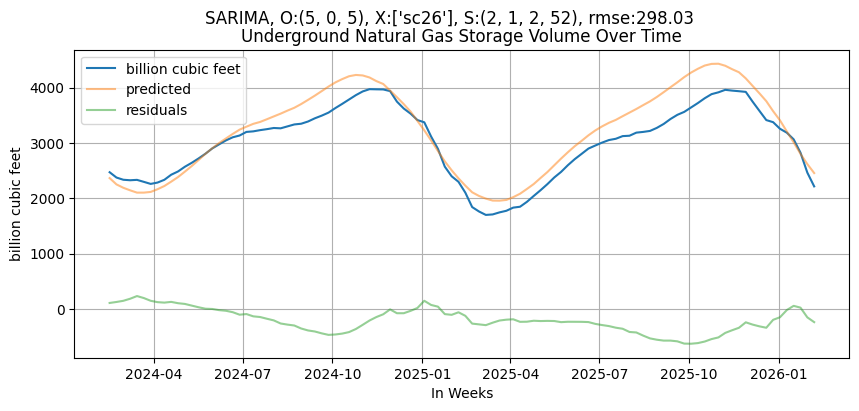

In [109]:
plot_model(df['Week ending'][-104:], label2[-104:], df_pred2, "SARIMA", loss2,\
           order=order, seasonal_order=seasonal_order, exog=["sc26"])